# 04.1 Otimização de Hiperparâmetros

## Contexto e Objetivo
Após a seleção dos melhores modelos no **Notebook 04**, esta etapa visa extrair o máximo desempenho através da busca sistemática de hiperparâmetros.

### Estratégia de Busca
- **Logistic Regression:** `GridSearchCV` (espaço de busca pequeno)
- **Random Forest:** `RandomizedSearchCV` (espaço de busca amplo)
- **Validação:** Stratified K-Fold (k=5)
- **Métrica principal de seleção (CV):** `roc_auc`

In [4]:
import numpy as np
import pandas as pd
import joblib
import time
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from scipy.stats import randint

# Carregamento das matrizes pré-processadas
data = np.load("../data/processed/train_test_data.npz")
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']

print(f"Dados de treino: {X_train.shape}")
print(f"Dados de teste:  {X_test.shape}")
print(f"Classes treino:  {np.bincount(y_train)}")
print(f"Classes teste:   {np.bincount(y_test)}")

Dados de treino: (242, 28)
Dados de teste:  (61, 28)
Classes treino:  [131 111]
Classes teste:   [33 28]


## 1. Configuração Comum
Definição da estratégia de Validação Cruzada Estratificada.

In [5]:
# Validação cruzada estratificada (mesma do Notebook 04)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métrica de otimização nativa do scikit-learn
scoring_metric = "roc_auc"

print(f"CV: {cv}")
print(f"Métrica de Otimização: {scoring_metric}")

CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Métrica de Otimização: roc_auc


## 2. Logistic Regression — GridSearchCV

In [6]:
param_grid_lr = {
    "C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "penalty": ["l2", "l1"],
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"]
}

lr = LogisticRegression(max_iter=2000, random_state=42)

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Iniciando GridSearchCV — Logistic Regression...")
start = time.time()
grid_lr.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nTempo: {elapsed:.1f}s")
print(f"Melhor ROC AUC (CV): {grid_lr.best_score_:.4f}")
print(f"Melhores parâmetros: {grid_lr.best_params_}")

Iniciando GridSearchCV — Logistic Regression...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Tempo: 16.8s
Melhor ROC AUC (CV): 0.9067
Melhores parâmetros: {'C': 1.0, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


c:\Users\cauae\Downloads\kebab-case\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\cauae\Downloads\kebab-case\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 3. Random Forest — RandomizedSearchCV

In [7]:
param_dist_rf = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 5, 10, 15, 20, 25],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

print("Iniciando RandomizedSearchCV — Random Forest...")
start = time.time()
random_rf.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nTempo: {elapsed:.1f}s")
print(f"Melhor ROC AUC (CV): {random_rf.best_score_:.4f}")
print(f"Melhores parâmetros: {random_rf.best_params_}")

Iniciando RandomizedSearchCV — Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tempo: 79.8s
Melhor ROC AUC (CV): 0.9040
Melhores parâmetros: {'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 11, 'n_estimators': 359}


## 4. Avaliação e Seleção do Modelo Vencedor (Validação Cruzada)
Decisão metodologicamente correta: Seleção baseada **exclusivamente** na performance da Validação Cruzada (`best_score_`).

In [8]:
# Comparação do desempenho no Cross-Validation
cv_comparison = pd.DataFrame([
    {"Modelo": "Logistic Regression (tuned)", "ROC AUC (CV)": grid_lr.best_score_},
    {"Modelo": "Random Forest (tuned)", "ROC AUC (CV)": random_rf.best_score_}
]).sort_values("ROC AUC (CV)", ascending=False)

print("=== Performance na Validação Cruzada ===")
print(cv_comparison.to_string(index=False))

# Seleção baseada no CV
if grid_lr.best_score_ >= random_rf.best_score_:
    best_model = grid_lr.best_estimator_
    best_model_name = "Logistic Regression (tuned)"
else:
    best_model = random_rf.best_estimator_
    best_model_name = "Random Forest (tuned)"

print(f"\nModelo Selecionado via CV: {best_model_name}")

=== Performance na Validação Cruzada ===
                     Modelo  ROC AUC (CV)
Logistic Regression (tuned)      0.906695
      Random Forest (tuned)      0.904021

Modelo Selecionado via CV: Logistic Regression (tuned)


## 5. Avaliação Final no Conjunto de Teste (Holdout)
Teste de generalização em dados não vistos.

In [9]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

results = [
    evaluate_model(grid_lr.best_estimator_, X_test, y_test, "Logistic Regression (tuned)"),
    evaluate_model(random_rf.best_estimator_, X_test, y_test, "Random Forest (tuned)")
]

results_df = pd.DataFrame(results).sort_values("ROC AUC", ascending=False)
print("=== Performance Final no Conjunto de Teste ===")
print(results_df.to_string(index=False))

=== Performance Final no Conjunto de Teste ===
                     Modelo  Accuracy  Precision   Recall       F1  ROC AUC
Logistic Regression (tuned)  0.852459   0.806452 0.892857 0.847458 0.958874
      Random Forest (tuned)  0.868852   0.812500 0.928571 0.866667 0.950216


## 6. Visualizações de Desempenho

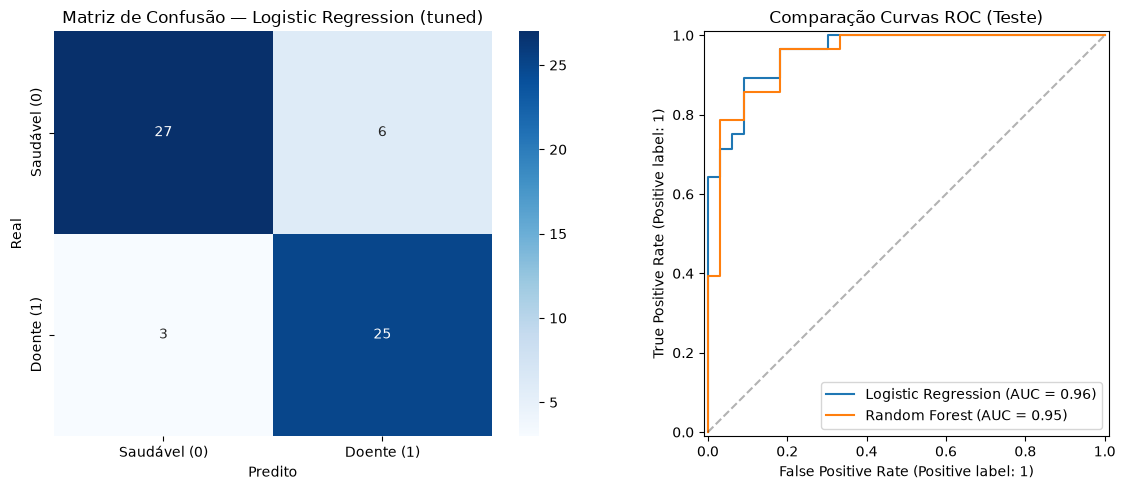

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusão do Modelo Selecionado
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f"Matriz de Confusão — {best_model_name}")
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")
axes[0].set_xticklabels(["Saudável (0)", "Doente (1)"])
axes[0].set_yticklabels(["Saudável (0)", "Doente (1)"])

# Curvas ROC comparativas
RocCurveDisplay.from_estimator(grid_lr.best_estimator_, X_test, y_test, ax=axes[1], name="Logistic Regression")
RocCurveDisplay.from_estimator(random_rf.best_estimator_, X_test, y_test, ax=axes[1], name="Random Forest")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title("Comparação Curvas ROC (Teste)")

plt.tight_layout()
plt.show()

## 7. Persistência dos Artefatos

In [11]:
best_model_filename = "../models/best_model_tuned.joblib"
joblib.dump(best_model, best_model_filename)

tuning_results = {
    "logistic_regression": {
        "best_params": grid_lr.best_params_,
        "best_cv_score": float(grid_lr.best_score_)
    },
    "random_forest": {
        "best_params": random_rf.best_params_,
        "best_cv_score": float(random_rf.best_score_)
    },
    "selected_model": best_model_name
}

with open("../models/tuning_results.json", "w") as f:
    json.dump(tuning_results, f, indent=2)

print(f"Modelo final salvo em: {best_model_filename}")
print(f"Resultados da busca salvos em: ../models/tuning_results.json")

Modelo final salvo em: ../models/best_model_tuned.joblib
Resultados da busca salvos em: ../models/tuning_results.json
